In [1]:
import sys, os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d  
import scipy
import pickle 
import uproot
print(uproot.__version__)

5.1.2


In [2]:
## -------------------------------- ##
##        SET PLOTTING STYLE        ##
## -------------------------------- ##
matplotlib.rcParams['figure.figsize'] = 8.5,6
matplotlib.rcParams['figure.subplot.left'] = 0.15
matplotlib.rcParams['figure.subplot.right'] = 0.88
matplotlib.rcParams['figure.subplot.bottom'] = 0.15
matplotlib.rcParams['figure.subplot.top'] = 0.88
matplotlib.rcParams['axes.titlesize'] = 20
matplotlib.rcParams['axes.labelsize'] = 18
matplotlib.rcParams['axes.labelweight'] = 'normal'
matplotlib.rcParams['font.weight'] = 'normal' 
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif'] = 'Times New Roman'
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['lines.linewidth'] = 2
matplotlib.rcParams['lines.markersize'] = 10
matplotlib.rcParams['xtick.labelsize'] = 16
matplotlib.rcParams['ytick.labelsize'] = 16
matplotlib.rcParams['xtick.major.size'] = 8
matplotlib.rcParams['ytick.major.size'] = 8
matplotlib.rcParams['xtick.minor.size'] = 4
matplotlib.rcParams['ytick.minor.size'] = 4
matplotlib.rcParams['xtick.minor.visible'] = True 
matplotlib.rcParams['ytick.minor.visible'] = True
matplotlib.rcParams['xtick.direction'] = 'in' 
matplotlib.rcParams['ytick.direction'] = 'in' 
matplotlib.rcParams['xtick.top'] = True 
matplotlib.rcParams['ytick.right'] = True
matplotlib.rcParams['xtick.major.pad'] = 6
matplotlib.rcParams['image.cmap'] = 'viridis'

In [36]:
## Open file
file1 = uproot.open('../Geant4_Sim/output/Spectrum_neutron_allXe_Point0phi_90theta.root')
file2 = uproot.open('../Geant4_Sim/output/Spectrum_neutron_0.5H2_Point0phi_90theta.root')
file3 = uproot.open('../Geant4_Sim/output/Spectrum_neutron_0.5He_Point0phi_90theta.root')

## Only one tree in each file
tree1 = file1['Events']
tree2 = file2['Events']
tree3 = file3['Events']

## Get branches of interest
prim_energy_KeV_1 = np.array(tree1['primaries.energy_keV'])
track_detName_1 = np.array(tree1['tracks.detectorName'])
track_energyDep_keV_1 = np.array(tree1['tracks.energyDeposition_keV'])
track_time_ns_1 = np.array(tree1['tracks.stepTime_ns'])
track_x_cm_1 = np.array(tree1['tracks.x_global_um'])*1e-4
track_y_cm_1 = np.array(tree1['tracks.y_global_um'])*1e-4
track_z_cm_1 = np.array(tree1['tracks.z_global_um'])*1e-4

prim_energy_KeV_2 = np.array(tree2['primaries.energy_keV'])
track_detName_2 = np.array(tree2['tracks.detectorName'])
track_energyDep_keV_2 = np.array(tree2['tracks.energyDeposition_keV'])
track_time_ns_2 = np.array(tree2['tracks.stepTime_ns'])
track_x_cm_2 = np.array(tree2['tracks.x_global_um'])*1e-4
track_y_cm_2 = np.array(tree2['tracks.y_global_um'])*1e-4
track_z_cm_2 = np.array(tree2['tracks.z_global_um'])*1e-4

prim_energy_KeV_3 = np.array(tree3['primaries.energy_keV'])
track_detName_3 = np.array(tree3['tracks.detectorName'])
track_energyDep_keV_3 = np.array(tree3['tracks.energyDeposition_keV'])
track_time_ns_3 = np.array(tree3['tracks.stepTime_ns'])
track_x_cm_3 = np.array(tree3['tracks.x_global_um'])*1e-4
track_y_cm_3 = np.array(tree3['tracks.y_global_um'])*1e-4
track_z_cm_3= np.array(tree3['tracks.z_global_um'])*1e-4

nEvents_1 = len(prim_energy_KeV_1)
nEvents_2 = len(prim_energy_KeV_2)
nEvents_3 = len(prim_energy_KeV_3)
print(f'{nEvents_1} primaries were simulated!')

1000000 primaries were simulated!


# Primary Neutron Spectra

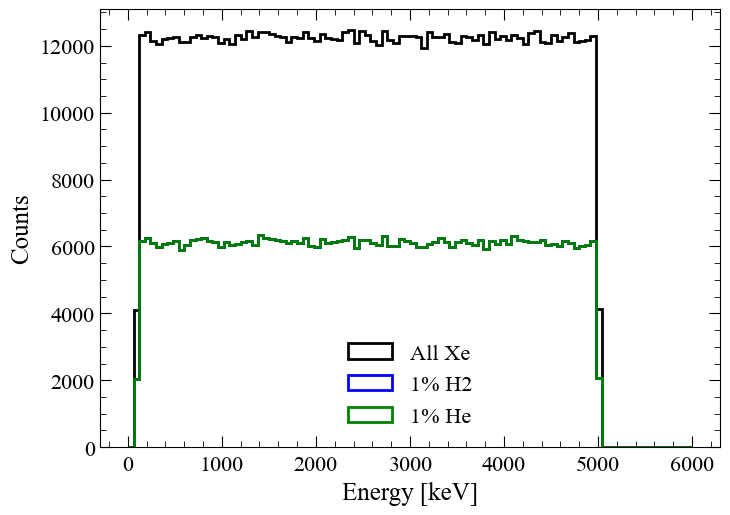

In [37]:
fig, ax = plt.subplots(1,1,dpi=100)

ax.hist(np.concatenate(prim_energy_KeV_1), bins=100, range=[0,6000], histtype='step', lw=2, color='black', label='All Xe')
ax.hist(np.concatenate(prim_energy_KeV_2), bins=100, range=[0,6000], histtype='step', lw=2, color='blue', label='1% H2')
ax.hist(np.concatenate(prim_energy_KeV_3), bins=100, range=[0,6000], histtype='step', lw=2, color='green', label='1% He')

ax.set_xlabel('Energy [keV]')
ax.set_ylabel('Counts')
ax.legend(frameon=False, loc='lower center', fontsize=16)

## Energy Deposited in TPC and Liquid Scint Detectors. Calculate T.o.F.

In [38]:
## Dumb function for doing some analysis and saving to arrays
def doSomeAnalysis(nEvents, track_detName, track_energyDep_keV, track_time_ns, track_x_cm, track_y_cm, track_z_cm):

    ## Energy deposited in each detector
    EdepkeV_dict = {'TPC':np.zeros(nEvents), 'PTFE':np.zeros(nEvents), 'ICV':np.zeros(nEvents), 'OCV':np.zeros(nEvents),
                    'LiqScintDet0deg':np.zeros(nEvents), 'LiqScintDet15deg':np.zeros(nEvents), 'LiqScintDet30deg':np.zeros(nEvents),
                    'LiqScintDet45deg':np.zeros(nEvents), 'LiqScintDet60deg':np.zeros(nEvents), 'LiqScintDet75deg':np.zeros(nEvents),
                    'LiqScintDet90deg':np.zeros(nEvents), 'LiqScintDet105deg':np.zeros(nEvents), 'LiqScintDet120deg':np.zeros(nEvents),
                    'LiqScintDet135deg':np.zeros(nEvents), 'LiqScintDet150deg':np.zeros(nEvents), 'LiqScintDet165deg':np.zeros(nEvents),
                    }
    ## position of recoil in TPC and liquid scintillator
    pos_TPC_cm = np.zeros((nEvents,3))
    pos_liqScint_cm = np.zeros((nEvents,3))
    ## time of recoil in TPC and liquid scint for time-of-flight
    time_TPC_ns = np.zeros(nEvents)
    time_liqScint_ns = np.zeros(nEvents)
    ## depends on liquid scintillator detector hit
    recoilAngle_deg = np.zeros(nEvents)

    ## Loop Through Events
    for idx in range(nEvents):
        
        if idx % 100000 == 0:
            print(f'On Event {idx}/{nEvents}')

        ## Loop through steps in tracks
        for jdx in range(len(track_detName[idx])):

            t_detName = track_detName[idx][jdx]
            t_Edep = track_energyDep_keV[idx][jdx]
            t_time_ns = track_time_ns[idx][jdx]
            t_x_cm = track_x_cm[idx][jdx]
            t_y_cm = track_y_cm[idx][jdx]
            t_z_cm = track_z_cm[idx][jdx]

            ## Energy deposit in each detector
            EdepkeV_dict[t_detName][idx] += t_Edep

            ## deposits in TPC
            if t_detName == 'TPC':
                time_TPC_ns[idx] += t_time_ns
                pos_TPC_cm[idx] = [t_x_cm, t_y_cm, t_z_cm]

            ## Hits on backing detector
            if (t_detName.find('LiqScintDet') != -1) and (time_liqScint_ns[idx] == 0):
                time_liqScint_ns[idx] = t_time_ns
                pos_liqScint_cm[idx] = [t_x_cm, t_y_cm, t_z_cm]
                
                angle = float(t_detName[len('LiqScintDet'):-len('deg')])
                recoilAngle_deg[idx] = angle
                
                break

    print('Done')
    return EdepkeV_dict, pos_TPC_cm, pos_liqScint_cm, time_TPC_ns, time_liqScint_ns, recoilAngle_deg

In [39]:
## Get analysis values
EdepkeV_dict_1, pos_TPC_cm_1, pos_liqScint_cm_1, time_TPC_ns_1, time_liqScint_ns_1, recoilAngle_deg_1 = \
    doSomeAnalysis(nEvents_1, track_detName_1, track_energyDep_keV_1, track_time_ns_1, track_x_cm_1, track_y_cm_1, track_z_cm_1)

EdepkeV_dict_2, pos_TPC_cm_2, pos_liqScint_cm_2, time_TPC_ns_2, time_liqScint_ns_2, recoilAngle_deg_2 = \
    doSomeAnalysis(nEvents_2, track_detName_2, track_energyDep_keV_2, track_time_ns_2, track_x_cm_2, track_y_cm_2, track_z_cm_2)

EdepkeV_dict_3, pos_TPC_cm_3, pos_liqScint_cm_3, time_TPC_ns_3, time_liqScint_ns_3, recoilAngle_deg_3 = \
    doSomeAnalysis(nEvents_3, track_detName_3, track_energyDep_keV_3, track_time_ns_3, track_x_cm_3, track_y_cm_3, track_z_cm_3)
    
timeOfFlight_ns_1 = time_liqScint_ns_1 - time_TPC_ns_1
timeOfFlight_ns_2 = time_liqScint_ns_2 - time_TPC_ns_2
timeOfFlight_ns_3 = time_liqScint_ns_3 - time_TPC_ns_3

On Event 0/1000000
On Event 100000/1000000
On Event 200000/1000000
On Event 300000/1000000
On Event 400000/1000000
On Event 500000/1000000
On Event 600000/1000000
On Event 700000/1000000
On Event 800000/1000000
On Event 900000/1000000
Done
On Event 0/500000
On Event 100000/500000
On Event 200000/500000
On Event 300000/500000
On Event 400000/500000
Done
On Event 0/500000
On Event 100000/500000
On Event 200000/500000
On Event 300000/500000
On Event 400000/500000
Done


# Plotting

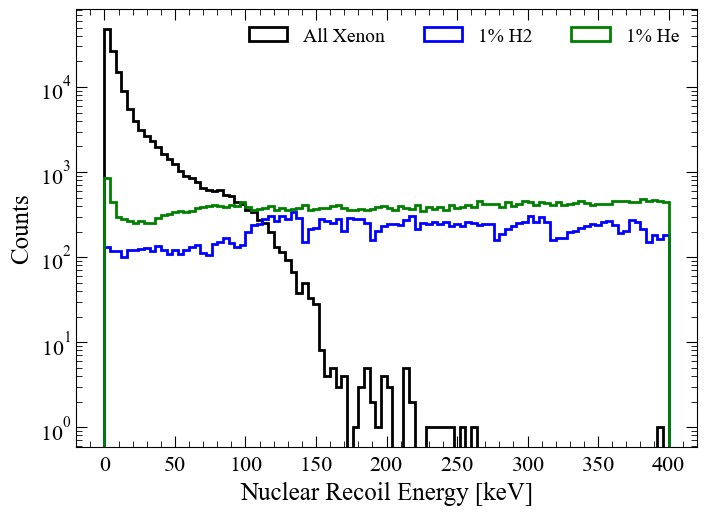

In [40]:
## Mask for Edep > 0. in TPC
mask_Edep_tpc_1 = EdepkeV_dict_1['TPC'] > 0.
mask_Edep_tpc_2 = EdepkeV_dict_2['TPC'] > 0.
mask_Edep_tpc_3 = EdepkeV_dict_3['TPC'] > 0.

fig, ax = plt.subplots(1,1,dpi=100)

ax.hist(EdepkeV_dict_1['TPC'][mask_Edep_tpc_1], bins=100, range=[0,400], lw=2, histtype='step', color='black', label='All Xenon')
ax.hist(EdepkeV_dict_2['TPC'][mask_Edep_tpc_2], bins=100, range=[0,400], lw=2, histtype='step', color='blue', label='1% H2')
ax.hist(EdepkeV_dict_3['TPC'][mask_Edep_tpc_3], bins=100, range=[0,400], lw=2, histtype='step', color='green', label='1% He')

ax.set_xlabel('Nuclear Recoil Energy [keV]')
ax.set_ylabel('Counts')
ax.set_yscale('log')
ax.legend(frameon=False, loc='upper right', fontsize=14, ncol=3)


487


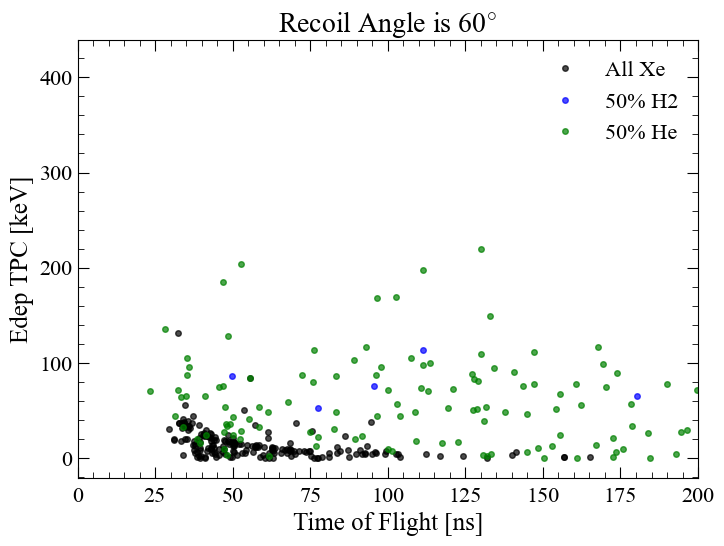

In [49]:
## mask for recoil Angle
recoilAngle = 60.

mask_ang_1 = np.where(recoilAngle_deg_1==recoilAngle, True, False)
mask_ang_2 = np.where(recoilAngle_deg_2==recoilAngle, True, False)
mask_ang_3 = np.where(recoilAngle_deg_3==recoilAngle, True, False)

print(len(mask_ang_2[mask_ang_2]))

fig, ax = plt.subplots(1,1,dpi=100)

ax.plot(timeOfFlight_ns_1[mask_Edep_tpc_1&mask_ang_1], EdepkeV_dict_1['TPC'][mask_Edep_tpc_1&mask_ang_1], 
        'o', color='black', markersize=4, alpha=0.7, label='All Xe')

ax.plot(timeOfFlight_ns_2[mask_Edep_tpc_2&mask_ang_2], EdepkeV_dict_2['TPC'][mask_Edep_tpc_2&mask_ang_2], 
        'o', color='blue', markersize=4, alpha=0.7, label='50% H2')

ax.plot(timeOfFlight_ns_3[mask_Edep_tpc_3&mask_ang_3], EdepkeV_dict_3['TPC'][mask_Edep_tpc_3&mask_ang_3], 
        'o', color='green', markersize=4, alpha=0.7, label='50% He')

ax.set_title(f'Recoil Angle is {recoilAngle:.0f}' + r'$^{\circ}$')
#ax.set_ylim(0,150)
ax.set_xlim(0,200)
ax.set_ylabel('Edep TPC [keV]')
ax.set_xlabel('Time of Flight [ns]')
ax.legend(frameon=False, loc='upper right', fontsize=16)

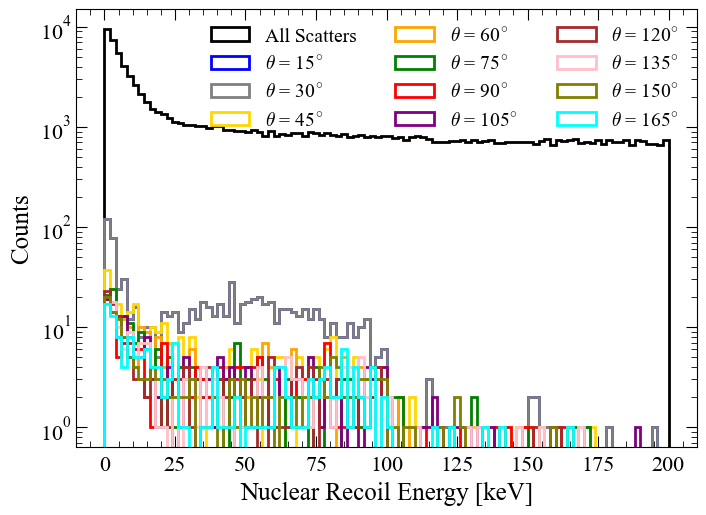

In [78]:
## Mask For Recoil Angle
mask_0deg = np.where(recoilAngle_deg==0., True, False)
mask_15deg = np.where(recoilAngle_deg==15., True, False)
mask_30deg = np.where(recoilAngle_deg==30., True, False)
mask_45deg = np.where(recoilAngle_deg==45., True, False)
mask_60deg = np.where(recoilAngle_deg==60., True, False)
mask_75deg = np.where(recoilAngle_deg==75., True, False)
mask_90deg = np.where(recoilAngle_deg==90., True, False)
mask_105deg = np.where(recoilAngle_deg==105., True, False)
mask_120deg = np.where(recoilAngle_deg==120., True, False)
mask_135deg = np.where(recoilAngle_deg==135., True, False)
mask_150deg = np.where(recoilAngle_deg==150., True, False)
mask_165deg = np.where(recoilAngle_deg==165., True, False)

## Mask for Edep > 0. in TPC
mask_Edep_tpc = EdepkeV_dict['TPC'] > 0.


## Plot
colors = ['gold','blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']

fig, ax = plt.subplots(1,1,dpi=100)

ax.hist(EdepkeV_dict['TPC'][mask_Edep_tpc], bins=100, range=[0,200], lw=2, histtype='step', color='black', label='All Scatters')
ax.hist(EdepkeV_dict['TPC'][mask_Edep_tpc&mask_15deg], bins=100, range=[0,200], lw=2, histtype='step', color='blue', label=r'$\theta$ = 15$^{\circ}$')
ax.hist(EdepkeV_dict['TPC'][mask_Edep_tpc&mask_15deg], bins=100, range=[0,200], lw=2, histtype='step', color='gray', label=r'$\theta$ = 30$^{\circ}$')
ax.hist(EdepkeV_dict['TPC'][mask_Edep_tpc&mask_45deg], bins=100, range=[0,200], lw=2, histtype='step', color='gold', label=r'$\theta$ = 45$^{\circ}$')
ax.hist(EdepkeV_dict['TPC'][mask_Edep_tpc&mask_60deg], bins=100, range=[0,200], lw=2, histtype='step', color='orange', label=r'$\theta$ = 60$^{\circ}$')
ax.hist(EdepkeV_dict['TPC'][mask_Edep_tpc&mask_75deg], bins=100, range=[0,200], lw=2, histtype='step', color='green', label=r'$\theta$ = 75$^{\circ}$')
ax.hist(EdepkeV_dict['TPC'][mask_Edep_tpc&mask_90deg], bins=100, range=[0,200], lw=2, histtype='step', color='red', label=r'$\theta$ = 90$^{\circ}$')
ax.hist(EdepkeV_dict['TPC'][mask_Edep_tpc&mask_105deg], bins=100, range=[0,200], lw=2, histtype='step', color='purple', label=r'$\theta$ = 105$^{\circ}$')
ax.hist(EdepkeV_dict['TPC'][mask_Edep_tpc&mask_120deg], bins=100, range=[0,200], lw=2, histtype='step', color='brown', label=r'$\theta$ = 120$^{\circ}$')
ax.hist(EdepkeV_dict['TPC'][mask_Edep_tpc&mask_135deg], bins=100, range=[0,200], lw=2, histtype='step', color='pink', label=r'$\theta$ = 135$^{\circ}$')
ax.hist(EdepkeV_dict['TPC'][mask_Edep_tpc&mask_150deg], bins=100, range=[0,200], lw=2, histtype='step', color='olive', label=r'$\theta$ = 150$^{\circ}$')
ax.hist(EdepkeV_dict['TPC'][mask_Edep_tpc&mask_165deg], bins=100, range=[0,200], lw=2, histtype='step', color='cyan', label=r'$\theta$ = 165$^{\circ}$')


ax.set_xlabel('Nuclear Recoil Energy [keV]')
ax.set_ylabel('Counts')
ax.set_yscale('log')
ax.legend(frameon=False, loc='upper right', fontsize=14, ncol=3)


Text(0.5, 0, 'Time of Flight [ns]')

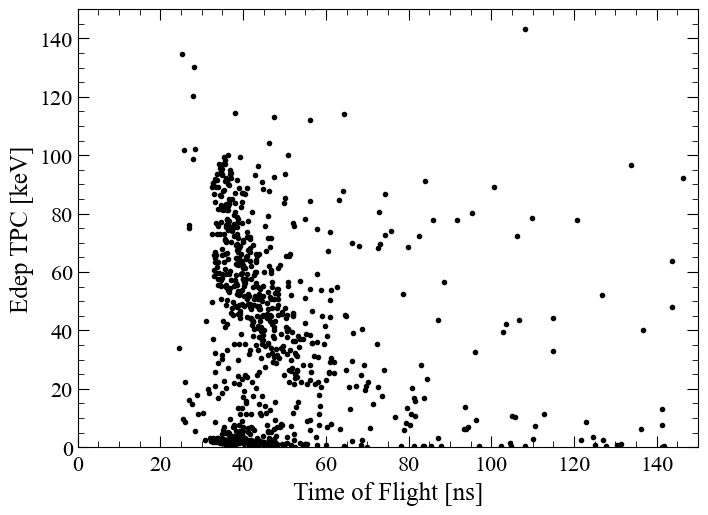

In [86]:
timeOfFlight_ns = time_liqScint_ns - time_TPC_ns

fig, ax = plt.subplots(1,1,dpi=100)

ax.plot(timeOfFlight_ns[mask_Edep_tpc&mask_15deg], EdepkeV_dict['TPC'][mask_Edep_tpc&mask_15deg], 
        'o', color='black', markersize=3)

ax.set_ylim(0,150)
ax.set_xlim(0,150)
ax.set_ylabel('Edep TPC [keV]')
ax.set_xlabel('Time of Flight [ns]')